In [51]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Load session
gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
ns_ = pd.DataFrame()
sc_ = pd.DataFrame()
ngs_ns_ = pd.DataFrame()
all_ = pd.DataFrame()

mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

for use_optimal_travel in [True, False]:
    for mouse, days in mouse_days.items():
        for day in days:

            # remove M22 
            if mouse == 22:
                continue

            [gcs, ngs, ns, sc, ngs_ns, all] = cell_classification_of1(mouse, day, use_optimal_travel=use_optimal_travel)
            _,_,_,_,_,clusters_VR = compute_vr_tcs(mouse, day)

            # add columns for all cells whether the use_optimal_travel is True or False
            for cells in [gcs, ngs, ns, sc, ngs_ns, all]:
                cells['use_optimal_travel'] = np.repeat(use_optimal_travel, len(cells))
                
            gcs = load_cluster_locations(clusters_VR, cells=gcs)
            ngs = load_cluster_locations(clusters_VR, cells=ngs)
            ns = load_cluster_locations(clusters_VR, cells=ns)
            sc = load_cluster_locations(clusters_VR, cells=sc)
            ngs_ns = load_cluster_locations(clusters_VR, cells=ngs_ns)
            all = load_cluster_locations(clusters_VR, cells=all)
            
            gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
            ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
            ns_ = pd.concat([ns_, ns], ignore_index=True)
            sc_ = pd.concat([sc_, sc], ignore_index=True)
            ngs_ns_ = pd.concat([ngs_ns_, ngs_ns], ignore_index=True)
            all_ = pd.concat([all_, all], ignore_index=True)

        print(f'there are this many cells at the moment, {len(all_)}')

20 14
optimal travel lag is 0.2502502502502537 cm
there are 169 non_grid and non_spatial_cells
there are 0 grid_cells
there are 93 non grid spatial cells
there are 76 non spatial cells
there are 35 speed cells
there are 204 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
20 15
optimal travel lag is 3.753753753753756 cm
there are 61 non_grid and non_spatial_cells
there are 1 grid_cells
there are 50 non grid spatial cells
there are 11 non spatial cells
there are 11 speed cells
there are 73 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
for the grid cells the unique locations are ['ENTm3']
20 16
optimal travel lag is 10.860860860860868 cm
there are 178 non_grid and non_spatial_cells
there are 3 grid_cells
there are 156 non grid spatial cells
there are 22 non spatial cells
there are 38 speed cells
there are 219 cells
for the non-grid spatial cells the unique locations are ['ENTm3']
for the grid cells t

lets run a sanity check to see if there is any difference in the plot depending on how we are classifying the cells

Plotting for use_optimal_travel=False


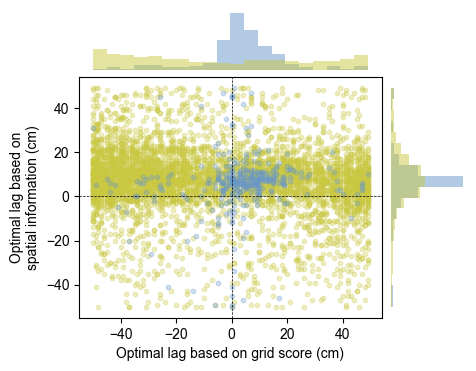

Plotting for use_optimal_travel=True


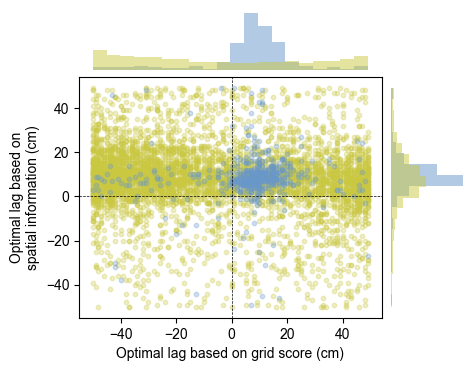

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec

for use_optimal_travel in [False, True]:
    print(f'Plotting for use_optimal_travel={use_optimal_travel}')
    
    # Prepare data
    gcs_df = gcs_.copy()
    ngs_df = ngs_.copy()
    gcs_df = gcs_df[gcs_df['use_optimal_travel'] == use_optimal_travel]
    ngs_df = ngs_df[ngs_df['use_optimal_travel'] == use_optimal_travel]

    # keep only mec ngs 
    ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')]
    gcs_df['group'] = 'GCS'
    ngs_df['group'] = 'NGS'
    combined = pd.concat([gcs_df, ngs_df], ignore_index=True)

    # Set up the figure with GridSpec
    fig = plt.figure(figsize=(5, 4))
    gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.05, hspace=0.05)

    ax_main = fig.add_subplot(gs[1, 0])
    ax_xhist = fig.add_subplot(gs[0, 0], sharex=ax_main)
    ax_yhist = fig.add_subplot(gs[1, 1], sharey=ax_main)

    ax_main.scatter(ngs_df['optimal_travel_lag_grid_score'], ngs_df['optimal_travel_lag'], color='#CAC841', alpha=0.3, s=10)
    ax_main.scatter(gcs_df['optimal_travel_lag_grid_score'], gcs_df['optimal_travel_lag'], color='#6897CD', alpha=0.3, s=10)

    ax_main.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax_main.axvline(0, color='black', linewidth=0.5, linestyle='--')
    ax_main.set_xlabel('Optimal lag based on grid score (cm)')
    ax_main.set_ylabel('Optimal lag based on\nspatial information (cm)')

    # X-axis histogram (top, horizontal bars)
    for group, color in zip(['GCS', 'NGS'], ['#6897CD', '#CAC841']):
        ax_xhist.hist(
            combined[combined['group'] == group]['optimal_travel_lag_grid_score'], density=True,
            bins=20, color=color, alpha=0.5, orientation='vertical', histtype='bar', linewidth=1
        )
    ax_xhist.axis('off')

    # Y-axis histogram (right, horizontal bars)
    for group, color in zip(['GCS', 'NGS'], ['#6897CD', '#CAC841']):
        ax_yhist.hist(
            combined[combined['group'] == group]['optimal_travel_lag'], density=True,
            bins=20, color=color, alpha=0.5, orientation='horizontal', histtype='bar', linewidth=1
        )
    ax_yhist.axis('off')
    fig.tight_layout()
    plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_lag_based_on_spatial_metrics.pdf', bbox_inches='tight')
    plt.show()

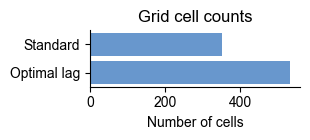

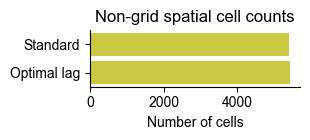

In [86]:
import matplotlib.pyplot as plt
import pandas as pd

# Count cells for gcs_ and ngs_ separately
gcs_counts = gcs_['use_optimal_travel'].value_counts().reindex([True, False], fill_value=0)
ngs_counts = ngs_['use_optimal_travel'].value_counts().reindex([True, False], fill_value=0)

labels = ['Optimal lag', 'Standard']

# Grid cells (GCS) horizontal bar plot
fig, ax = plt.subplots(figsize=(3.2, 1.5))
ax.barh(labels, gcs_counts.values, color=['#6897CD', '#6897CD'])
ax.set_title('Grid cell counts')
ax.set_xlabel('Number of cells')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/classified_GC.pdf', bbox_inches='tight')
plt.show()

# Non-grid spatial cells (NGS) horizontal bar plot
fig, ax = plt.subplots(figsize=(3.2, 1.5))
ax.barh(labels, ngs_counts.values, color=['#CAC841', '#CAC841'])
ax.set_title('Non-grid spatial cell counts')
ax.set_xlabel('Number of cells')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/classified_NGS.pdf', bbox_inches='tight')
plt.show()

We can see there is a clear difference in the number of classified grid cells when using the optimal travel lag or not, however this isn't the case for non-grid spatial cells. The spatial information score is thus sufficiently high at travel=0 to surpass the shuffled threshold. We can test the spatial information and grid scores measured at the optimal travel versus travel = 0

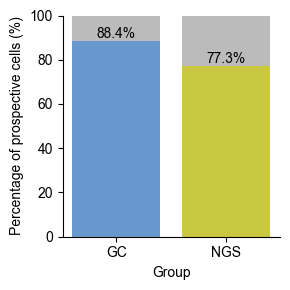

In [85]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()
gcs_df = gcs_df[gcs_df['brain_region'].str.contains('ENT')]
ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')]
gcs_df['group'] = 'GC'
ngs_df['group'] = 'NGS'
combined = pd.concat([gcs_df, ngs_df], ignore_index=True)

# Calculate proportions
prop_df = combined.groupby('group')['optimal_travel_lag'].apply(
    lambda x: pd.Series({
        'Predictive': (x > 0).sum(),
        'Non-predictive': (x <= 0).sum()
    })
).unstack()

prop_percent = prop_df.div(prop_df.sum(axis=1), axis=0) * 100

# Stacked bar plot with Predictive on bottom
fig, ax = plt.subplots(figsize=(3, 3))
bars_pred = ax.bar(
    prop_percent.index,
    prop_percent['Predictive'],
    color=['#6897CD', '#CAC841'],
    label='Predictive'
)
bars_nonpred = ax.bar(
    prop_percent.index,
    prop_percent['Non-predictive'],
    bottom=prop_percent['Predictive'],
    color=['#bbbbbb', '#bbbbbb'],
    label='Non-predictive'
)

# Annotate percentage on top of Predictive group
for bar, pct in zip(bars_pred, prop_percent['Predictive']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_ylabel('Percentage of prospective cells (%)')
ax.set_xlabel('Group')
ax.set_ylim(0, 100)
ax.set_xticks(range(len(prop_percent.index)))
ax.set_xticklabels(prop_percent.index)
ax.legend().remove()  # Remove legend
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/prospective_cells_percentage.pdf', bbox_inches='tight')
plt.show()

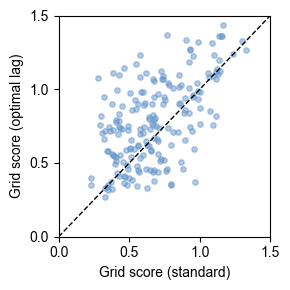

In [89]:
import matplotlib.pyplot as plt

# Filter for matching rows by mouse, day, and cluster_id
gcs_true = gcs_[gcs_['use_optimal_travel'] == True]
gcs_false = gcs_[gcs_['use_optimal_travel'] == False]

# Merge on mouse, day, cluster_id to get paired grid_scores
paired = pd.merge(
    gcs_true[['mouse', 'day', 'cluster_id', 'grid_score']],
    gcs_false[['mouse', 'day', 'cluster_id', 'grid_score']],
    on=['mouse', 'day', 'cluster_id'],
    suffixes=('_true', '_false')
).dropna()

# Scatter plot
plt.figure(figsize=(3, 3))
plt.xticks(np.arange(0,1.6,0.5))
plt.yticks(np.arange(0,1.6,0.5))
plt.xlim(0, 1.5)
plt.ylim(0, 1.5)
plt.scatter(paired['grid_score_false'], paired['grid_score_true'], color='#6897CD', alpha=0.5, s=15)
plt.plot([0,1.5],[0,1.5],color='black', linestyle='--', linewidth=1)  # Unity line
plt.xlabel('Grid score (standard)')
plt.ylabel('Grid score (optimal lag)')
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/grid_score_standard_vs_optimal_GC.pdf', bbox_inches='tight')
plt.show()

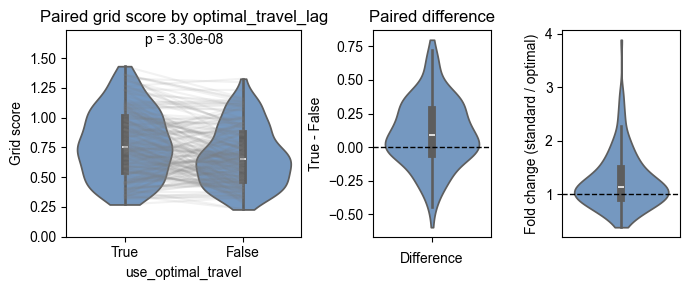

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# Filter for matching rows by mouse, day, and cluster_id
gcs_true = gcs_[gcs_['use_optimal_travel'] == True]
gcs_false = gcs_[gcs_['use_optimal_travel'] == False]

# Merge on mouse, day, cluster_id to get paired grid_scores
paired = pd.merge(
    gcs_true[['mouse', 'day', 'cluster_id', 'grid_score']],
    gcs_false[['mouse', 'day', 'cluster_id', 'grid_score']],
    on=['mouse', 'day', 'cluster_id'],
    suffixes=('_true', '_false')
).dropna()

# Paired t-test
tstat, pval = ttest_rel(paired['grid_score_true'], paired['grid_score_false'])

# Prepare data for violin plot
plot_df = pd.DataFrame({
    'grid_score': pd.concat([paired['grid_score_true'], paired['grid_score_false']], ignore_index=True),
    'use_optimal_travel': ['True'] * len(paired) + ['False'] * len(paired)
})

# Prepare data for difference plot
diff = paired['grid_score_true'] - paired['grid_score_false']

# Prepare data for fold change plot
fold_change = paired['grid_score_true'] / paired['grid_score_false']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7, 3), gridspec_kw={'width_ratios': [2, 1, 1]})

# Violin plot
sns.violinplot(data=plot_df, x='use_optimal_travel', y='grid_score', palette={'True': '#6897CD', 'False': '#6897CD'}, ax=ax1, inner='box', cut=0)
ax1.set_xlabel('use_optimal_travel')
ax1.set_ylabel('Grid score')
ax1.set_title('Paired grid score by optimal_travel_lag')

# Draw lines connecting paired points
for i in range(len(paired)):
    ax1.plot(
        [0, 1],
        [paired.iloc[i]['grid_score_true'], paired.iloc[i]['grid_score_false']],
        color='gray',
        alpha=0.1
    )

# Place p-value above the highest flier
ymax = plot_df['grid_score'].max()
ymax += (ymax * 0.1)
ax1.set_ylim(0, ymax + (ymax * 0.1))
ax1.text(0.5, ymax + (ymax * 0.01), f'p = {pval:.2e}', ha='center', va='bottom', fontsize=10)

# Difference plot
sns.violinplot(y=diff, ax=ax2, color='#6897CD', inner='box', cut=0)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Difference')
ax2.set_ylabel('True - False')
ax2.set_title('Paired difference')

# Fold change plot
sns.violinplot(y=fold_change, ax=ax3, color='#6897CD', inner='box', cut=0)
ax3.axhline(1, color='black', linestyle='--', linewidth=1)
ax3.set_ylabel('Fold change (standard / optimal)')
ax3.set_xticks([])  # Hide x-ticks for fold change plot
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/grid_score_change_standard_versus_optimal_GC.pdf', bbox_inches='tight')
plt.show()

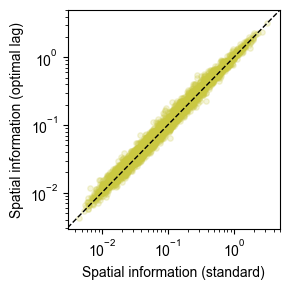

In [82]:
import matplotlib.pyplot as plt

# Filter for matching rows by mouse, day, and cluster_id
ngs_true = ngs_[ngs_['use_optimal_travel'] == True]
ngs_false = ngs_[ngs_['use_optimal_travel'] == False]

# Merge on mouse, day, cluster_id to get paired grid_scores
paired = pd.merge(
    ngs_true[['mouse', 'day', 'cluster_id', 'spatial_information_score']],
    ngs_false[['mouse', 'day', 'cluster_id', 'spatial_information_score']],
    on=['mouse', 'day', 'cluster_id'],
    suffixes=('_true', '_false')
).dropna()

# Scatter plot
plt.figure(figsize=(3, 3))
plt.scatter(paired['spatial_information_score_false'], paired['spatial_information_score_true'], color='#CAC841', alpha=0.2, s=15)
plt.plot([0,10],[0,10],color='black', linestyle='--', linewidth=1)  # Unity line
# set x and y to logathmic scale
plt.xscale('log')
plt.yscale('log')
plt.xlim(None, 5)
plt.ylim(None, 5)
plt.xlabel('Spatial information (standard)')
plt.ylabel('Spatial information (optimal lag)')
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/spatial_information_standard_vs_optimal_NGS.pdf', bbox_inches='tight')
plt.show()

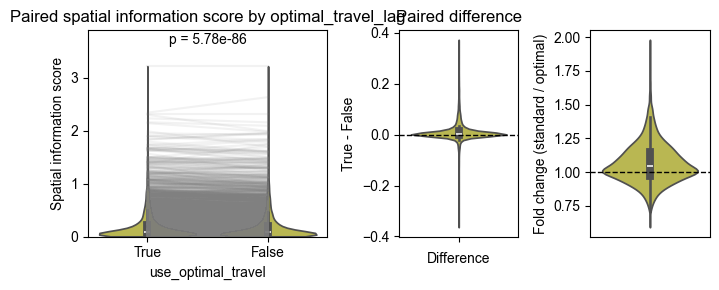

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# Paired t-test
tstat, pval = ttest_rel(paired['spatial_information_score_true'], paired['spatial_information_score_false'])

# Prepare data for violin plot
plot_df = pd.DataFrame({
    'spatial_information_score': pd.concat([paired['spatial_information_score_true'], paired['spatial_information_score_false']], ignore_index=True),
    'use_optimal_travel': ['True'] * len(paired) + ['False'] * len(paired)
})

# Prepare data for difference plot
diff = paired['spatial_information_score_true'] - paired['spatial_information_score_false']

# Prepare data for fold change plot
fold_change = paired['spatial_information_score_true'] / paired['spatial_information_score_false']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7, 3), gridspec_kw={'width_ratios': [2, 1, 1]})

# Violin plot
sns.violinplot(data=plot_df, x='use_optimal_travel', y='spatial_information_score', palette={'True': '#CAC841', 'False': '#CAC841'}, ax=ax1, inner='box', cut=0)
ax1.set_xlabel('use_optimal_travel')
ax1.set_ylabel('Spatial information score')
ax1.set_title('Paired spatial information score by optimal_travel_lag')

# Draw lines connecting paired points
for i in range(len(paired)):
    ax1.plot(
        [0, 1],
        [paired.iloc[i]['spatial_information_score_true'], paired.iloc[i]['spatial_information_score_false']],
        color='gray',
        alpha=0.1
    )

# Place p-value above the highest flier
ymax = plot_df['spatial_information_score'].max()
ymax += (ymax * 0.1)
ax1.set_ylim(0, ymax + (ymax * 0.1))
ax1.text(0.5, ymax + (ymax * 0.01), f'p = {pval:.2e}', ha='center', va='bottom', fontsize=10)

# Difference plot
sns.violinplot(y=diff, ax=ax2, color='#CAC841', inner='box', cut=0)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Difference')
ax2.set_ylabel('True - False')
ax2.set_title('Paired difference')

# Fold change plot
sns.violinplot(y=fold_change, ax=ax3, color='#CAC841', inner='box', cut=0)
ax3.axhline(1, color='black', linestyle='--', linewidth=1)
ax3.set_ylabel('Fold change (standard / optimal)')
ax3.set_xticks([])  # Hide x-ticks for fold change plot
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/spatial_information_change_standard_versus_optimal_NGS.pdf', bbox_inches='tight')
plt.show()

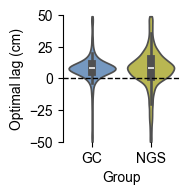

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

gcs_df = gcs_.copy()
ngs_df = ngs_.copy() 
# Add group labels
gcs_df['group'] = 'GC'
ngs_df['group'] = 'NGS'

# Combine data
combined = pd.concat([gcs_df, ngs_df], ignore_index=True)

fig, ax = plt.subplots(figsize=(2, 2))
# Create violin plot
sns.violinplot(data=combined, x='group', y='optimal_travel_lag', palette={'GC': '#6897CD', 'NGS': '#CAC841'}, cut=0, inner='box', ax=ax)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Group')
ax.set_ylabel('Optimal lag (cm)')
ax.set_ylim(-50, 50)
ax.set_xticks([0, 1])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_spatial_information_lag_by_cell_type.pdf', bbox_inches='tight')
plt.show()